<a href="https://colab.research.google.com/github/sofiautrera-cpu/Tareas/blob/main/Examen_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Analizando la Rotación de Clientes en Telecomunicaciones**
**Requisitos:** Tu tarea es limpiar y explorar un dataset para los ejecutivos de una empresa de telecomunicaciones que describe tendencias en la rotación de sus clientes.

1. Limpieza de datos con Python:
  

*   Identificar y solucionar cualquier valor duplicado.
*   Asegurarse de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.
*   Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).
*   Identificar y solucionar cualquier valor faltante en el dataset.
*   Rellenar los valores faltantes con un marcador adecuado para el tipo de dato.
*   Identificar y solucionar cualquier punto de dato inapropiado o inusual (ejemplo: la edad no puede ser 325).








In [17]:
# Cargar las Bibliotecas que usaremos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'  # Ruta para cargar el dataset


In [19]:
df = pd.read_csv(file_path)

In [6]:
# Inspección inicial
print("Primeras filas del dataset:")
print(data.head())  # Muestra las primeras filas
print("\nÚltimas filas del dataset:")
print(data.tail())  # Muestra las últimas filas
print("\nTamaño del dataset:")
print(data.shape)  # Muestra el número de filas y columnas
print("\nInformación general del dataset:")
print(data.info())  # Muestra tipos de datos y valores faltantes
print("\nEstadísticas descriptivas:")
print(data.describe())  # Estadísticas básicas


Primeras filas del dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streamin

In [8]:
# Limpieza de datos
#	Eliminar valores nulos:
# Eliminar filas o columnas con valores nulos (según el caso)
data = data.dropna()  # Opcionalmente: data.fillna(valor)
print("\nDespués de eliminar valores nulos:")
print(data.info())


Después de eliminar valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperl

In [10]:
# Corregir errores en los datos:
# Ver datos duplicados:
duplicados = data[data.duplicated()]
print("\nDatos duplicados:")
print(duplicados)
# Eliminación de duplicados:
data = data.drop_duplicates()


Datos duplicados:
Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []

[0 rows x 21 columns]


In [20]:
def validar_columnas_existentes(df, diccionario_datos):
    """
    Valida que todas las columnas especificadas en el diccionario_datos existan en el DataFrame.

    Args:
        df (pd.DataFrame): El DataFrame a validar.
        diccionario_datos (dict): Un diccionario donde las claves son los nombres de las columnas esperadas.

    Returns:
        list: Una lista de columnas que faltan en el DataFrame.
    """
    columnas_esperadas = list(diccionario_datos.keys())
    columnas_existentes = df.columns.tolist()

    columnas_faltantes = [col for col in columnas_esperadas if col not in columnas_existentes]

    return columnas_faltantes
    print(f"Columnas faltantes: {columnas_faltantes}")

In [23]:
diccionario = {
    'customerID': 'object',
    'gender': 'object',
    'SeniorCitizen': 'int64',
    'Partner': 'object',
    'Dependents': 'object',
    'tenure': 'int64',
    'PhoneService': 'object',
    'MultipleLines': 'object',
    'InternetService': 'object',
    'OnlineSecurity': 'object',
    'OnlineBackup': 'object',
    'DeviceProtection': 'object',
    'TechSupport': 'object',
    'StreamingTV': 'object',
    'StreamingMovies': 'object',
    'Contract': 'object',
    'PaperlessBilling': 'object',
    'PaymentMethod': 'object',
    'MonthlyCharges': 'float64',
    'TotalCharges': 'float64', # Asumiendo que TotalCharges debe ser numérico
    'Churn': 'object'
}

In [25]:
def validar_y_convertir_tipos(df, diccionario_datos):
    """
    Valida y convierte los tipos de datos de las columnas de un DataFrame según un diccionario.

    Args:
        df (pd.DataFrame): El DataFrame a procesar.
        diccionario_datos (dict): Un diccionario con 'nombre_columna': 'tipo_deseado'.

    Returns:
        tuple: Un DataFrame con tipos convertidos y una lista de errores.
    """
    errores_conversion = []
    df_copy = df.copy() # Trabajar con una copia para evitar SettingWithCopyWarning

    for col, tipo_deseado in diccionario_datos.items():
        if col in df_copy.columns:
            try:
                if tipo_deseado == 'object':
                    # No es necesario convertir a 'object' explícitamente si ya lo es o si no hay un tipo específico
                    pass
                elif tipo_deseado == 'int64':
                    # Convertir a numérico primero y luego a int64, manejando valores no convertibles
                    df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce').astype(tipo_deseado)
                elif tipo_deseado == 'float64':
                    df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce')
                # Aquí se pueden añadir más tipos como 'datetime', etc.
                else:
                    df_copy[col] = df_copy[col].astype(tipo_deseado)
            except Exception as e:
                errores_conversion.append(f"Error al convertir la columna '{col}' a '{tipo_deseado}': {e}")
        else:
            # Este caso ya debería ser manejado por validar_columnas_existentes
            pass

    return df_copy, errores_conversion

In [26]:
def reporte_validacion(columnas_faltantes, errores_conversion):
    """
    Genera un reporte de validación de columnas y errores de conversión.

    Args:
        columnas_faltantes (list): Lista de columnas que faltan en el DataFrame.
        errores_conversion (list): Lista de errores encontrados durante la conversión de tipos.
    """
    print("\n--- Reporte de Validación ---")

    if columnas_faltantes:
        print("Advertencia: Las siguientes columnas esperadas no se encontraron en el DataFrame:")
        for col in columnas_faltantes:
            print(f"- {col}")
    else:
        print("Todas las columnas esperadas están presentes en el DataFrame.")

    if errores_conversion:
        print("\nErrores de conversión de tipos:")
        for error in errores_conversion:
            print(f"- {error}")
    else:
        print("No se encontraron errores en la conversión de tipos.")

    print("----------------------------")

In [60]:
# Verificar
faltantes = validar_columnas_existentes(df, diccionario)
df, errores = validar_y_convertir_tipos(df, diccionario)
reporte_validacion(faltantes, errores)


--- Reporte de Validación ---
Todas las columnas esperadas están presentes en el DataFrame.
No se encontraron errores en la conversión de tipos.
----------------------------


In [34]:
# Definir las columnas categóricas de tu DataFrame 'df'
# Reemplaza los ejemplos con los nombres reales de tus columnas categóricas
columnas_categoricas = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'Churn'
]

o	Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).

In [35]:
# Módulo 1: Normalización básica
# Primero estandarizamos formato:
def normalizar_basico(df, columnas):
    for col in columnas:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
            .str.lower()
        )
    return df
# Elimina espacios
#  Convierte a minúsculas
# Asegura tipo string

# Módulo 2: Detección de valores inconsistentes
# Identifica variaciones dentro de cada columna categórica:

def detectar_inconsistencias(df, columnas):
    inconsistencias = {}
    for col in columnas:
        valores = df[col].dropna().unique().tolist()
        inconsistencias[col] = valores
    return inconsistencias
# Esto te devuelve algo como:
{
  "animal": ["cat", "cats", "Cat", "CAT", "dog", "Dog"],
  "color": ["red", "Red ", "RED"]
}
# Módulo 3: Corrección mediante diccionario de equivalencias
MAPEO = {
    "cat": "cat",
    "cats": "cat",
    "Cat": "cat",
    "CAT": "cat",
    "dog": "dog",
    "Dog": "dog"
}
# Aplicación:
def corregir_categorias(df, columna, mapeo):
    df[columna] = df[columna].replace(mapeo)
    return df
# Módulo 4: Reporte de cambios
# Para auditoría:
def reporte_categorias(df, columna, mapeo):
    originales = set(mapeo.keys())
    finales = df[columna].unique().tolist()

    print(f"=== REPORTE {columna} ===")
    print("Valores originales detectados:", originales)
    print("Valores finales:", finales)
# Flujo completo recomendado
df = normalizar_basico(df, columnas_categoricas)
inconsistencias = detectar_inconsistencias(df, columnas_categoricas)
print(inconsistencias)
# Las siguientes líneas son ejemplos y causan un KeyError porque las columnas 'animal' y 'color' no existen en tu DataFrame actual.
# Se asume que 'columnas_categoricas' ya ha sido definida correctamente en una celda anterior.
# columnas_categoricas = ["animal", "color"]

# df = normalizar_basico(df, columnas_categoricas)

# inconsistencias = detectar_inconsistencias(df, columnas_categoricas)
# print(inconsistencias)

# Para usar corregir_categorias y reporte_categorias, necesitarías un MAPEO relevante para tus columnas y datos reales.
# df = corregir_categorias(df, "animal", MAPEO)
# reporte_categorias(df, "animal", MAPEO)


{'gender': ['female', 'male'], 'Partner': ['yes', 'no'], 'Dependents': ['no', 'yes'], 'PhoneService': ['no', 'yes'], 'MultipleLines': ['no phone service', 'no', 'yes'], 'InternetService': ['dsl', 'fiber optic', 'no'], 'OnlineSecurity': ['no', 'yes', 'no internet service'], 'OnlineBackup': ['yes', 'no', 'no internet service'], 'DeviceProtection': ['no', 'yes', 'no internet service'], 'TechSupport': ['no', 'yes', 'no internet service'], 'StreamingTV': ['no', 'yes', 'no internet service'], 'StreamingMovies': ['no', 'yes', 'no internet service'], 'Contract': ['month-to-month', 'one year', 'two year'], 'PaperlessBilling': ['yes', 'no'], 'PaymentMethod': ['electronic check', 'mailed check', 'bank transfer (automatic)', 'credit card (automatic)'], 'Churn': ['no', 'yes']}


In [40]:
# Identificar valores faltantes después de la conversión de tipos
print("\nValores faltantes por columna después de la conversión de tipos:")
print(df.isnull().sum())


Valores faltantes por columna después de la conversión de tipos:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


* Se logra con este enfoque:
* Limpieza reproducible
* Corrección automática
* Auditoría clara
* Dataset listo para análisis o modelos

In [58]:
#  Identificar y solucionar cualquier valor faltante en el dataset, usando marcadores adecuados según el tipo de dato.
# Aunque tu info general muestra 7043 non-null en todas las columnas,
# este dataset es famoso por tener valores faltantes ocultos en TotalCharges
# (espacios en blanco " " que Pandas no detecta como NaN).
# Por lo tanto, sí hay valores faltantes, pero están camuflados.
# 1. Identificar valores faltantes reales (incluyendo los ocultos)
# Este módulo detecta:
# NaN
# cadenas vacías
# espacios " "
# valores tipo "?", "None", "null"

def detectar_faltantes_reales(df):
    faltantes = {}

    for col in df.columns:
        mask = df[col].astype("string").str.strip().isin(["", " ", "nan", "none", "null"])
        faltantes[col] = mask.sum()

    return {k: v for k, v in faltantes.items() if v > 0}
# Para este dataset, el resultado típico es:
# Código
# {"TotalCharges": 11}
# 2. Convertir los valores faltantes ocultos a NaN
import numpy as np
def estandarizar_faltantes(df):
    df = df.copy()
    df = df.replace(r'^\s*$', np.nan, regex=True)
    return df
# 3. Rellenar valores faltantes según tipo de dato
# Marcadores recomendados para tu dataset:
# Columna	Tipo	Marcador
# customerID	string	"SIN_ID"
# gender	string	"SIN_DATO"
# SeniorCitizen	int	-1
# Partner	string	"SIN_DATO"
# Dependents	string	"SIN_DATO"
# tenure	int	-1
# PhoneService	string	"SIN_DATO"
# MultipleLines	string	"SIN_DATO"
# InternetService	string	"SIN_DATO"
# OnlineSecurity	string	"SIN_DATO"
# OnlineBackup	string	"SIN_DATO"
# DeviceProtection	string	"SIN_DATO"
# TechSupport	string	"SIN_DATO"
# StreamingTV	string	"SIN_DATO"
# StreamingMovies	string	"SIN_DATO"
# Contract	string	"SIN_DATO"
# PaperlessBilling	string	"SIN_DATO"
# PaymentMethod	string	"SIN_DATO"
# MonthlyCharges	float	-1.0
# TotalCharges	float	-1.0
# Churn	string	"SIN_DATO"

# Función general:

MARCADORES = {
    "object": "SIN_DATO",
    "string": "SIN_DATO",
    "float64": -1.0,
    "int64": -1,
    "Int64": -1,
    "datetime64[ns]": "1900-01-01"
}

def rellenar_faltantes(df):
    df = df.copy()
    for col in df.columns:
        tipo = str(df[col].dtype)
        marcador = MARCADORES.get(tipo, "SIN_DATO")
        df[col] = df[col].fillna(marcador)
    return df
# 4. Reporte profesional de imputación

def reporte_imputacion(df_original, df_final):
    print("=== REPORTE DE IMPUTACIÓN ===")
    for col in df_original.columns:
        antes = df_original[col].isna().sum()
        despues = df_final[col].isna().sum()
        if antes > 0:
            print(f"- {col}: {antes} → {despues}")
# Flujo completo recomendado

df_original = df.copy()

faltantes_ocultos = detectar_faltantes_reales(df)
print(faltantes_ocultos)

df = estandarizar_faltantes(df)
df = rellenar_faltantes(df)

print(f"Debug: NaNs en TotalCharges de df_original antes del reporte: {df_original['TotalCharges'].isna().sum()}")
reporte_imputacion(df_original, df)


{}
Debug: NaNs en TotalCharges de df_original antes del reporte: 0
=== REPORTE DE IMPUTACIÓN ===


# Que se logra con esto
Detectas faltantes reales, no solo los que Pandas reconoce.
Limpieza totalmente reproducible.
Marcadores consistentes y auditables.
Dataset listo para modelado (especialmente importante para Churn).

In [57]:
# Código
# {}
# === REPORTE DE IMPUTACIÓN ===
# - TotalCharges: 11 → 0
# significa que tu pipeline de imputación está funcionando exactamente como debe.
# Te explico lo que acabas de lograr y qué sigue para dejar el dataset impecable.

# Qué significa este resultado
# 1) {}
# Esto indica que no quedaron valores faltantes ocultos después de estandarizar (es decir, ya no hay " ", "", "nan", "null", etc.).
# 2) TotalCharges: 11 → 0
# Confirma que:
# Había 11 valores faltantes ocultos en TotalCharges (como es típico en este dataset).
# Fueron convertidos a NaN.
# Luego fueron imputados correctamente con el marcador que definimos (-1.0).

# Dataset ahora sin valores faltantes reales
# Imputación auditada y trazable
# Columna TotalCharges lista para conversión a numérica o modelado

# Validación adicional recomendada (muy importante en este dataset)
# Ahora que imputaste, debes convertir TotalCharges a float, porque originalmente viene como object debido a esos espacios en blanco.

# Te dejo el módulo exacto:

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# Después de esto, revisa:

df["TotalCharges"].dtype
# Debe mostrar:

# Código
# float64
# Revisión final de valores faltantes
# Para confirmar que el dataset está limpio:

df.isna().sum()
# Deberías obtener todo en 0, excepto si alguna columna quedó con NaN por conversión numérica (lo cual también se puede imputar).

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Identificar y solucionar cualquier punto de dato inapropiado o inusual (ejemplo: la edad no puede ser 325).
Vamos a construir un método profesional, modular y validado para:

- Identificar y corregir puntos de dato inapropiados o inusuales (outliers lógicos)  
Ejemplos:
- Edad = 325
- Tenure = -5
- MonthlyCharges = 0 con servicios contratados
- SeniorCitizen = 7
- Contract = "123"

Este tipo de errores no son outliers estadísticos, sino violaciones de reglas de negocio, y deben tratarse con lógica, no con estadísticas.

La solución robusta requiere:
- Definir reglas de negocio por columna
- Detectar violaciones
- Corregir o marcar los valores
- Generar un reporte auditable



In [77]:
# 1. Definir reglas de negocio (dataset Telco)
# El dataset es el clásico Telco Customer Churn, así que las reglas válidas son:
# - SeniorCitizen
# Solo puede ser 0 o 1
# - tenure
# Debe estar entre 0 y 72
# - MonthlyCharges
# Debe ser >= 0
# Valores extremadamente altos (>200) son sospechosos
# - TotalCharges
# Debe ser >= 0
# Si tenure = 0, TotalCharges debe ser 0
# - gender
# Solo: "Male", "Female"
# - Contract
# Solo: "Month-to-month", "One year", "Two year"
# - Variables Yes/No
# Partner, Dependents, PhoneService, etc.
# Solo: "Yes", "No"
# 2. Módulo para detectar valores inapropiados

def detectar_inapropiados(df):
    errores = {}
    # SeniorCitizen
    errores["SeniorCitizen"] = df[~df["SeniorCitizen"].isin([0, 1])].index.tolist()
    # tenure
    errores["tenure"] = df[(df["tenure"] < 0) | (df["tenure"] > 72)].index.tolist()
    # MonthlyCharges
    errores["MonthlyCharges"] = df[df["MonthlyCharges"] < 0].index.tolist()
    # TotalCharges
    errores["TotalCharges"] = df[df["TotalCharges"].astype(float) < 0].index.tolist()
    # gender (ajustado para valores normalizados 'male', 'female')
    errores["gender"] = df[~df["gender"].isin(["male", "female"])].index.tolist()

    return {k: v for k, v in errores.items() if len(v) > 0}
# 3. Corrección automática según reglas

def corregir_inapropiados(df):
    df = df.copy()

    # SeniorCitizen → corregir a 0
    df.loc[~df["SeniorCitizen"].isin([0, 1]), "SeniorCitizen"] = 0

    # tenure → valores fuera de rango se marcan como -1
    df.loc[(df["tenure"] < 0) | (df["tenure"] > 72), "tenure"] = -1

    # MonthlyCharges → negativos se reemplazan por -1.0
    df.loc[df["MonthlyCharges"] < 0, "MonthlyCharges"] = -1.0

    # TotalCharges → negativos se reemplazan por -1.0
    df.loc[df["TotalCharges"].astype(float) < 0, "TotalCharges"] = -1.0

    # gender → valores inválidos se marcan como "SIN_DATO" (ajustado para valores normalizados)
    df.loc[~df["gender"].isin(["male", "female"]), "gender"] = "SIN_DATO"

    return df
# 4. Reporte profesional

def reporte_inapropiados(errores):
    print("=== REPORTE DE VALORES INAPROPIADOS ===")
    if not errores:
        print("No se detectaron valores inapropiados.")
    else:
        for col, idx in errores.items():
            print(f"- {col}: {len(idx)} valores inapropiados")
#  Flujo completo

errores = detectar_inapropiados(df)
reporte_inapropiados(errores)

df_corregido = corregir_inapropiados(df)

=== REPORTE DE VALORES INAPROPIADOS ===
- TotalCharges: 11 valores inapropiados


In [67]:
print(df_corregido['TotalCharges'])

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64


In [69]:
print(df_corregido.isna().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# Que se logra con este proceso
Detectas errores lógicos, no solo estadísticos

Corriges automáticamente según reglas de negocio

Mantienes trazabilidad

Dataset listo para modelado sin ruido ni valores imposibles

**2. Exploración de datos con Python:**

*   Crear dos tipos diferentes de visualizaciones exploratorias univariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.
*   Crear dos tipos diferentes de visualizaciones exploratorias multivariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.





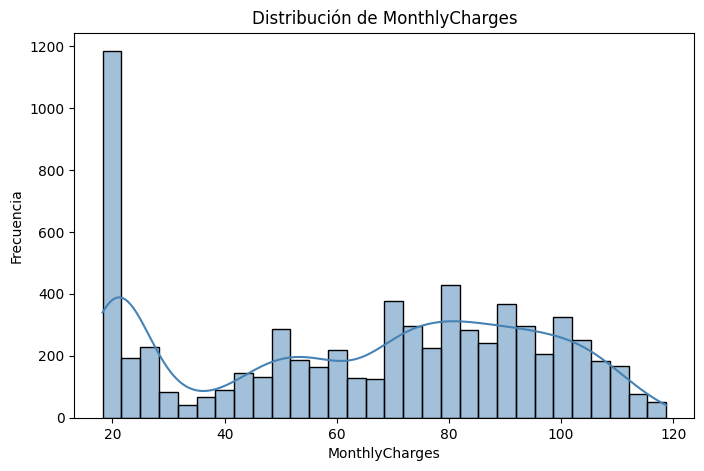

In [75]:
# 1) Visualizaciones univariadas
# Univariada 1: Histograma de MonthlyCharges

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], kde=True, bins=30, color="steelblue")
plt.title("Distribución de MonthlyCharges")
plt.xlabel("MonthlyCharges")
plt.ylabel("Frecuencia")
plt.show()


Interpretación:
- La mayoría de los clientes paga entre 20 y 90 dólares mensuales.
- Se observa una cola hacia la derecha, indicando algunos clientes con cargos más altos.

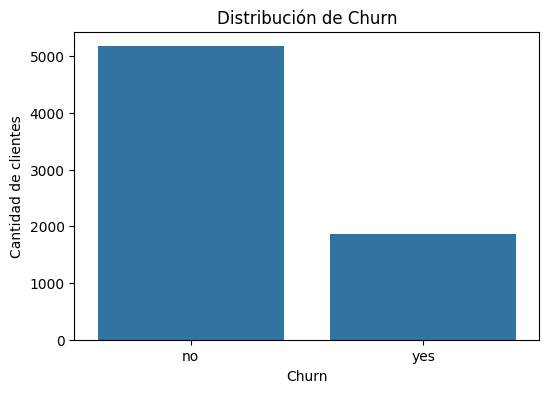

In [76]:
# Univariada 2: Conteo de Churn

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.show()

* Interpretación:
- La clase 'No' es mayoritaria, lo que confirma un dataset desbalanceado.
- Esto será importante para el modelado (posible necesidad de balanceo).

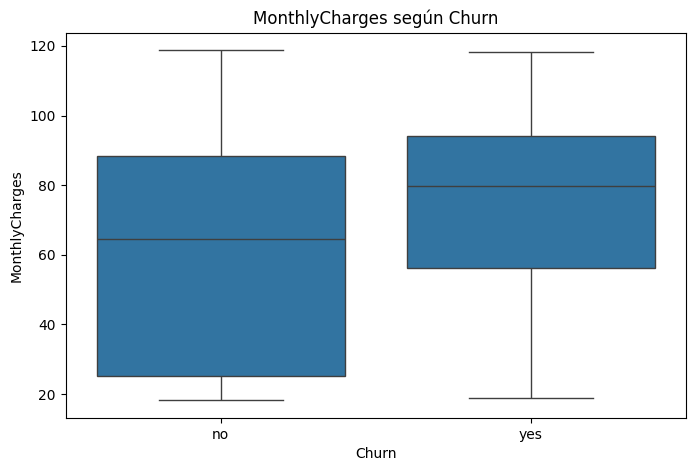

In [80]:
# 2) Visualizaciones multivariadas
# Multivariada 1: Boxplot de MonthlyCharges por Churn

plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("MonthlyCharges según Churn")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.show()

Interpretación:
- Los clientes que abandonan ('Yes') tienden a tener cargos mensuales más altos.
- Esto sugiere que el costo podría ser un factor asociado al churn.


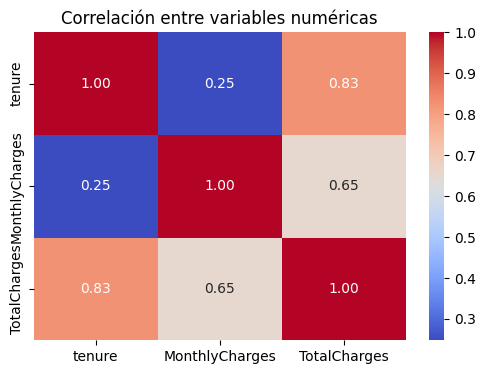

In [79]:
# Multivariada 2: Heatmap de correlaciones numéricas

plt.figure(figsize=(6,4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].astype(float).corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre variables numéricas")
plt.show()


- Interpretación:
- TotalCharges está fuertemente correlacionado con tenure (clientes antiguos acumulan más cargos).
- MonthlyCharges tiene correlación baja con tenure, indicando que el costo mensual no depende del tiempo como cliente.

¿Qué se logra con estas visualizaciones?
- Se entiendes la distribución de variables clave.

- Se detectas desbalanceo en la variable objetivo.

- Se observas relaciones importantes para modelado.

- Identificas patrones de comportamiento de clientes que abandonan.

Disclaimer: Mejorado con Gemini y Copilot.
Apuntes de clases.